<a href="https://colab.research.google.com/github/ALAAMEKAWY56/ASL-Classification-CNN/blob/main/ASL_Alphabet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os

#1- Load Dataset


In [ ]:
!pip install kaggle==1.6.17

os.environ['KAGGLE_USERNAME'] = 'alaaMekawi'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_c43d74bafd927812cdb5e34e64d0c6f2'


!kaggle datasets download -d grassknoted/asl-alphabet


!unzip -nq asl-alphabet.zip -d asl_alphabet_colab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for kaggle: filename=kaggle-1.6.17-py3-none-any.whl size=105787 sha256=7d2fc20f6ef6a7a3e7c52c0b1dad4df7b4245b5d8caa562c007842b6740a033e
  Stored in directory: /root/.cache/pip/wheels/46/d2/26/84d0a1acdb9c6baccf7d28cf06962ec80529fe1ad938489983
Successfully built kaggle
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.0
    Uninstalling kaggle-2.0.0:
      Successfully uninstalled kaggle-2.0.0
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
 99% 1.02G/1.03G [00:08<00:00, 213MB/s]
100% 1.03G/1.03G [00:08<00:00, 130MB/s]


In [ ]:
!ls asl_alphabet_colab/asl_alphabet_train/asl_alphabet_train

A  C  del  F  H  J  L  N	O  Q  S      T	V  X  Z
B  D  E    G  I  K  M  nothing	P  R  space  U	W  Y


# Load Train Dataset


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
'asl_alphabet_colab/asl_alphabet_train/asl_alphabet_train',
 validation_split=0.2,
 subset="training",
 seed=123,
 image_size = (64 , 64),
 batch_size = 32)


Found 87000 files belonging to 29 classes.
Using 69600 files for training.


# Load Test Dataset

In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "asl_alphabet_colab/asl_alphabet_train/asl_alphabet_train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64,64),
    batch_size=32
)

Found 87000 files belonging to 29 classes.
Using 17400 files for validation.


In [ ]:
print(train_ds.class_names)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [ ]:
for images , labels in train_ds.take(1):
  print(labels[:20])

tf.Tensor([18 22 12 19  4 14 13  2  0  9  7  7 19  1 21 25 14 24 19 18], shape=(20,), dtype=int32)


#2- Check Shape of Images

*   32 -> batch size
*   128 -> image height
*   128 -> image width
*   3   -> RGB channels





In [ ]:
for images  , labels in train_ds.take(1):
  print(images.shape)

(32, 64, 64, 3)


#3- Visualize

In [ ]:
import matplotlib.pyplot as plt

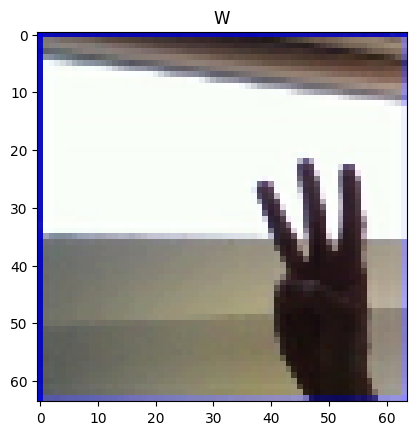

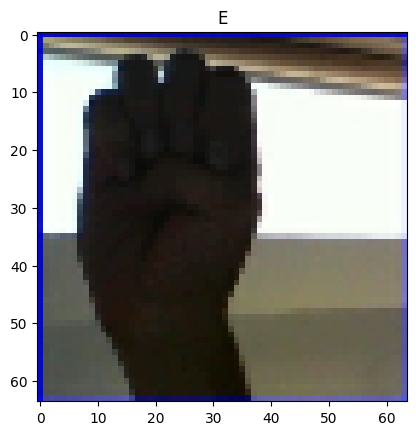

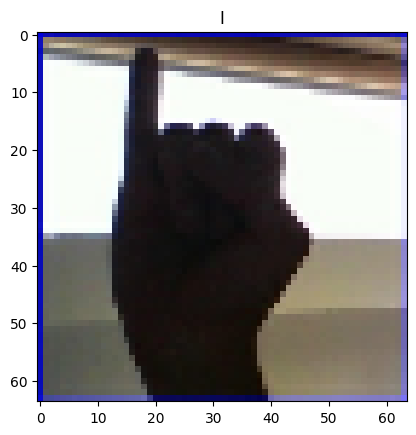

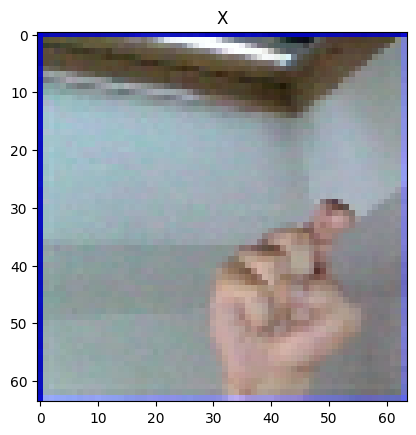

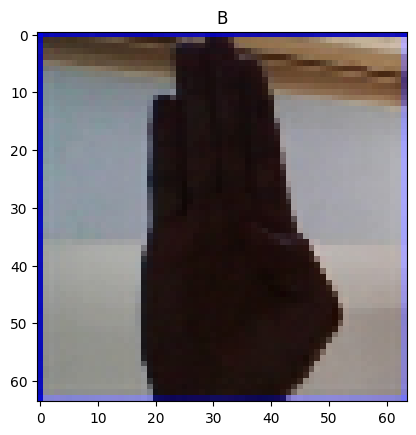

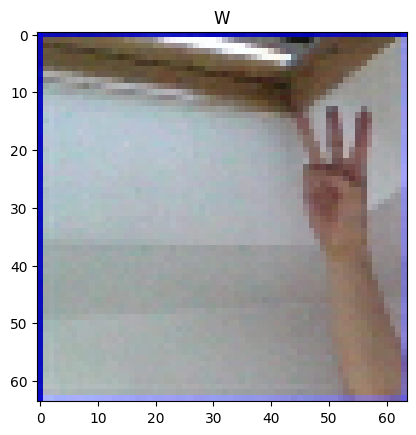

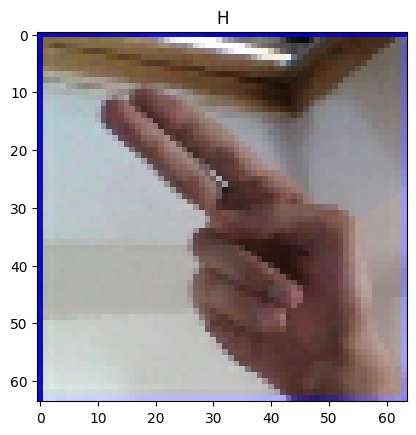

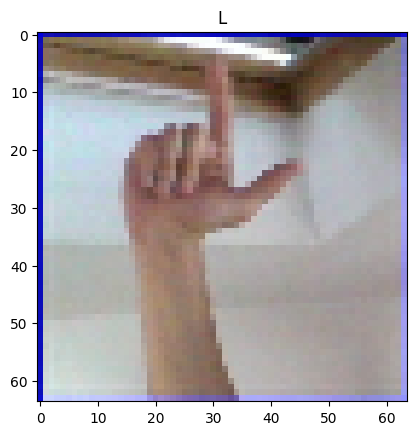

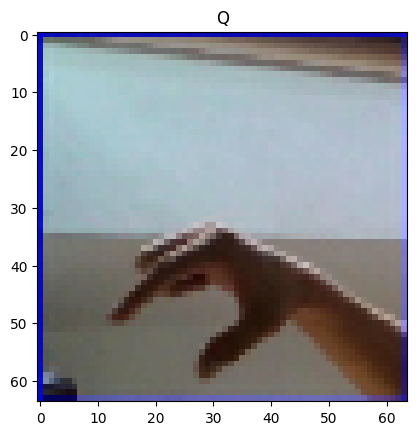

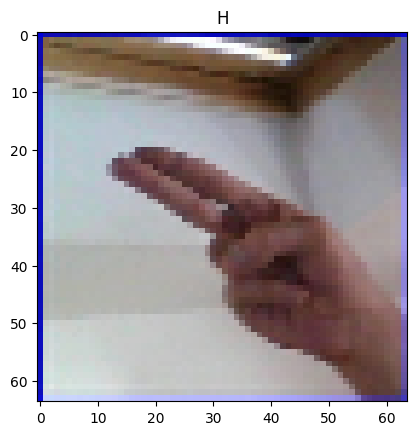

In [ ]:
class_names = train_ds.class_names
for images , labels in train_ds.take(1):
  for i in range(10):
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.show()

#4- Normalization

In image datasets, pixel values usually range from **0 to 255**.  
However, neural networks perform better when the input values are **scaled to a smaller range**.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [ ]:
model = Sequential([
    Input(shape = (64 , 64 , 3) , name = 'Input_layer'),
    Rescaling(1./255),

    Conv2D(32 , (3,3) , activation = 'relu' , name = 'CNN_layer_1'),
    MaxPooling2D((2,2)),

    Conv2D(64 , (3,3) , activation = 'relu' , name = 'CNN_layer_2'),
    MaxPooling2D((2,2)),

    Conv2D(128 , (3,3) , activation = 'relu' , name = 'CNN_layer_3'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256 , activation = 'relu' , name = 'hidden_layer_1'),
    Dense(256 , activation = 'relu' , name = 'hidden_layer_2'),
    Dropout(0.1),
    Dense(29 , activation = 'softmax' , name = 'output_layer')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_layer_1 (Conv2D)            │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_layer_2 (Conv2D)            │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CNN_layer_3 (Conv2D)            │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_1 (Dense)          │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,346,397 (5.14 MB)

 Trainable params: 1,346,397 (5.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
optimizer = Adam(learning_rate = 0.0005)

In [ ]:
model.compile(optimizer= optimizer , loss = 'sparse_categorical_crossentropy'
, metrics = ['accuracy'])

In [ ]:
from IPython.core import history

In [ ]:
history = model.fit(
    train_ds ,
    epochs = 15,
    validation_data = val_ds
)

Epoch 1/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 46s 18ms/step - accuracy: 0.7149 - loss: 0.9119 - val_accuracy: 0.9429 - val_loss: 0.1850
Epoch 2/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9581 - loss: 0.1228 - val_accuracy: 0.9757 - val_loss: 0.0701
Epoch 3/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9809 - loss: 0.0592 - val_accuracy: 0.9875 - val_loss: 0.0350
Epoch 4/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9883 - loss: 0.0364 - val_accuracy: 0.9806 - val_loss: 0.0635
Epoch 5/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.9894 - loss: 0.0343 - val_accuracy: 0.9945 - val_loss: 0.0173
Epoch 6/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.9937 - loss: 0.0216 - val_accuracy: 0.9906 - val_loss: 0.0288
Epoch 7/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9934 - loss: 0.0212 - val_accuracy: 0.9937 - val_loss: 0.0210
Epoch 8/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 37s 17ms/step - accuracy: 0.9943 -

In [ ]:
print(tf.__version__)

2.19.0


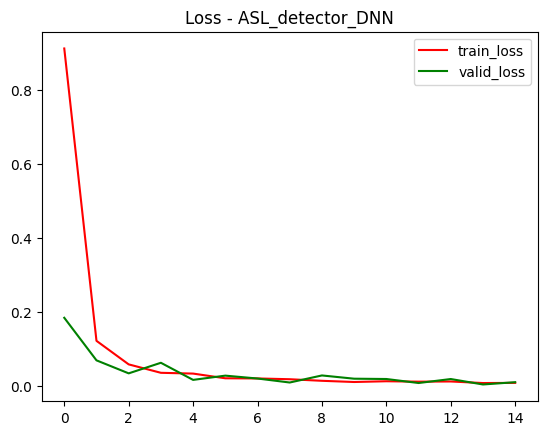

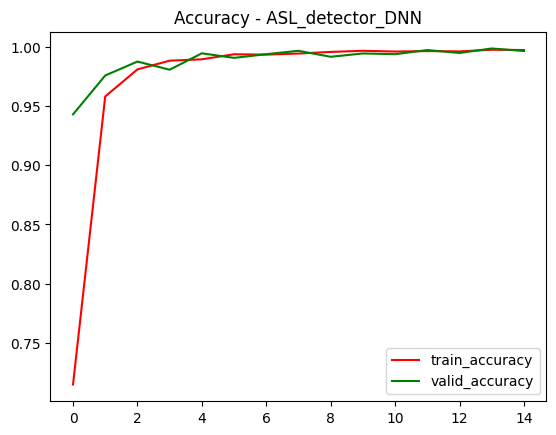

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_acc(history, model_name='model_1'):
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

plot_loss_acc(history, model_name='ASL_detector_DNN')